Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score


Load Dataset

In [3]:
df = pd.read_csv("/content/food_app_customer_data.csv")

In [4]:
df.head()

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Membership_upgrade,Avg_Order_Value,Preferred_Cuisine,Weekend_Order_Ratio,App_Rating,Avg_Delivery_Tips,Discount_Usage_Freq,Total_Cuisines_Tried,Avg_Delivery_Time,Last_Month_Complaints
0,CUST1000,Connor Rowland,40,Female,52777,27,Gold,5.2,0.0,46.16,Indian,0.55,3,5.37,High,8,32.4,0
1,CUST1001,Cameron Miles MD,28,Female,65910,84,Basic,12.2,0.0,95.62,Healthy,0.60,4,8.33,Medium,6,41.1,1
2,CUST1002,Dennis Price,63,Male,56731,51,Silver,2.9,1.0,69.89,Chinese,0.44,4,8.01,Low,5,47.3,0
3,CUST1003,Jessica Jones,23,Female,40559,56,Platinum,11.1,0.0,44.56,Healthy,0.55,5,3.82,Low,9,32.2,0
4,CUST1004,Kevin Bauer,38,Male,79675,74,Basic,10.7,0.0,52.27,Indian,0.28,3,6.14,Medium,2,37.7,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             2000 non-null   object 
 1   Name                   2000 non-null   object 
 2   Age                    2000 non-null   int64  
 3   Gender                 2000 non-null   object 
 4   Annual_Income          2000 non-null   int64  
 5   Spending_Score         2000 non-null   int64  
 6   Membership_Level       2000 non-null   object 
 7   Purchase_Frequency     2000 non-null   float64
 8   Membership_upgrade     1800 non-null   float64
 9   Avg_Order_Value        2000 non-null   float64
 10  Preferred_Cuisine      2000 non-null   object 
 11  Weekend_Order_Ratio    2000 non-null   float64
 12  App_Rating             2000 non-null   int64  
 13  Avg_Delivery_Tips      2000 non-null   float64
 14  Discount_Usage_Freq    2000 non-null   object 
 15  Tota

In [6]:
df.describe()

,Age,Annual_Income,Spending_Score,Purchase_Frequency,Membership_upgrade,Avg_Order_Value,Weekend_Order_Ratio,App_Rating,Avg_Delivery_Tips,Total_Cuisines_Tried,Avg_Delivery_Time,Last_Month_Complaints
count,2000.00000,2000.000000,2000.000000,2000.000000,1800.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,43.57150,59849.506000,50.469500,8.000450,0.258333,59.801245,0.50023,3.68050,5.981770,5.391500,34.867050,0.150000
std,15.13137,14451.507584,29.059289,3.987447,0.437840,23.216109,0.15014,1.10092,3.008745,2.814816,9.487338,0.357161
min,18.00000,9857.000000,1.000000,1.000000,0.000000,7.410000,0.08000,1.00000,0.820000,1.000000,15.000000,0.000000
25%,30.00000,49818.500000,25.000000,4.600000,0.000000,41.782500,0.39000,3.00000,3.710000,3.000000,28.200000,0.000000
50%,43.00000,60036.500000,51.000000,8.000000,0.000000,56.560000,0.50000,4.00000,5.350000,5.000000,34.950000,0.000000
75%,57.00000,69631.500000,76.000000,11.500000,1.000000,75.117500,0.61000,5.00000,7.702500,8.000000,41.400000,0.000000
max,69.00000,110053.000000,100.000000,15.000000,1.000000,135.770000,0.93000,5.00000,17.700000,10.000000,60.000000,1.000000


# Data Cleaning

Missing Values

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Name,0
Age,0
Gender,0
Annual_Income,0
Spending_Score,0
Membership_Level,0
Purchase_Frequency,0
Membership_upgrade,200
Avg_Order_Value,0


In [7]:
# Feature Engineering (innovation points)
df['Income_per_Order'] = df['Annual_Income'] / (df['Purchase_Frequency'] + 1)
df['Tip_to_Order_Ratio'] = df['Avg_Delivery_Tips'] / df['Avg_Order_Value'].astype(float)  # Engineered feature
df['Complaints_per_Order'] = df['Last_Month_Complaints'] / (df['Purchase_Frequency'] + 1)
df['High_Value'] = ((df['Annual_Income'] > df['Annual_Income'].quantile(0.75)) &
                    (df['Spending_Score'] > df['Spending_Score'].quantile(0.75))).astype(int)
df['Low_Rating'] = (df['App_Rating'].map({'Low':1, 'Medium':0.5, 'High':0}).fillna(0) > 0.5).astype(int)


In [8]:
df.head()

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Membership_upgrade,Avg_Order_Value,...,Avg_Delivery_Tips,Discount_Usage_Freq,Total_Cuisines_Tried,Avg_Delivery_Time,Last_Month_Complaints,Income_per_Order,Tip_to_Order_Ratio,Complaints_per_Order,High_Value,Low_Rating
0,CUST1000,Connor Rowland,40,Female,52777,27,Gold,5.2,0.0,46.16,...,5.37,High,8,32.4,0,8512.419355,0.116334,0.000000,0,0
1,CUST1001,Cameron Miles MD,28,Female,65910,84,Basic,12.2,0.0,95.62,...,8.33,Medium,6,41.1,1,4993.181818,0.087116,0.075758,0,0
2,CUST1002,Dennis Price,63,Male,56731,51,Silver,2.9,1.0,69.89,...,8.01,Low,5,47.3,0,14546.410256,0.114609,0.000000,0,0
3,CUST1003,Jessica Jones,23,Female,40559,56,Platinum,11.1,0.0,44.56,...,3.82,Low,9,32.2,0,3351.983471,0.085727,0.000000,0,0
4,CUST1004,Kevin Bauer,38,Male,79675,74,Basic,10.7,0.0,52.27,...,6.14,Medium,2,37.7,0,6809.829060,0.117467,0.000000,0,0


Compare Basic vs Platinum Users

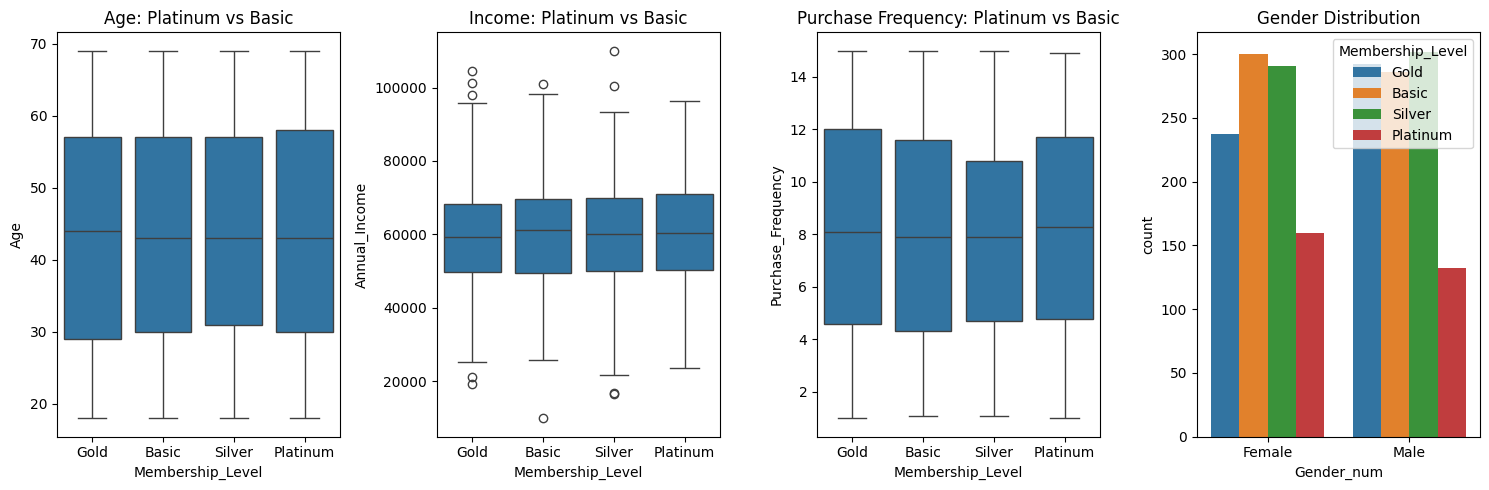

In [10]:
## 1.1 Demographic Profile: Platinum vs Basic
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
basic_demo = df[df['Membership_Level'] == df['Membership_Level'].map({'Basic':0}).idxmin()]  # Approximate Basic/Platinum
sns.boxplot(data=df, x='Membership_Level', y='Age')
plt.title('Age: Platinum vs Basic')

plt.subplot(1,4,2)
sns.boxplot(data=df, x='Membership_Level', y='Annual_Income')
plt.title('Income: Platinum vs Basic')

plt.subplot(1,4,3)
sns.boxplot(data=df, x='Membership_Level', y='Purchase_Frequency')
plt.title('Purchase Frequency: Platinum vs Basic')


plt.subplot(1,4,4)
df['Gender_num'] = df['Gender']
sns.countplot(data=df, x='Gender_num', hue='Membership_Level')
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()


Age: Platinum and Basic users have almost identical age distribution (median ~43–44 years), so age is not a strong factor for membership upgrade.

Income: Basic users actually show a slightly higher median income ($61K)   than Platinum users (~$60K), indicating income alone does not drive upgrades.

Gender: Females have a higher number of Platinum memberships than males, suggesting women may be slightly more likely to adopt premium tiers.

Correlation Analysis

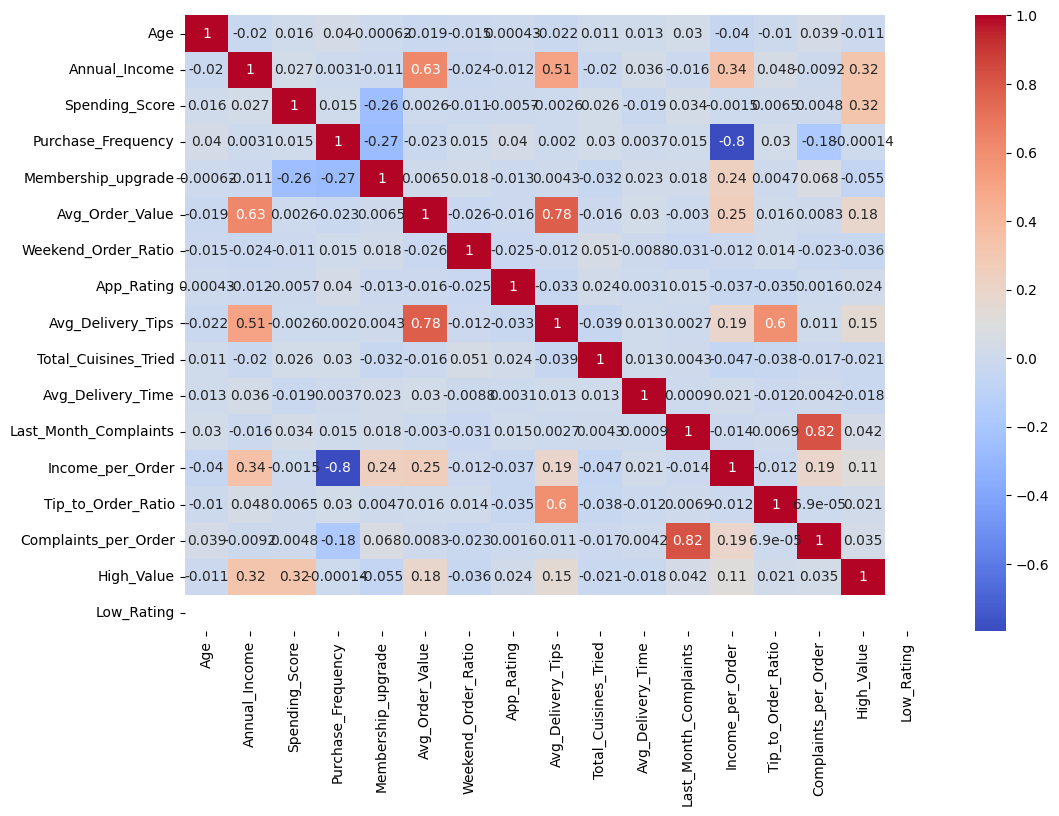

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()



* **Income has no impact:** The correlation between **Annual Income and membership upgrade is almost zero**, meaning **people with higher salary are not more likely to upgrade**.

* **Power users upgrade less:** **Purchase Frequency and Spending Score show negative correlation**, meaning **customers who already buy frequently or spend a lot are less likely to upgrade**.

* **Important Insight:** **Upgrades are more likely from medium-engagement users**, not the highest spenders. This means the marketing team should **target regular users who are engaged but not the biggest buyers yet**.


Service Quality Impact

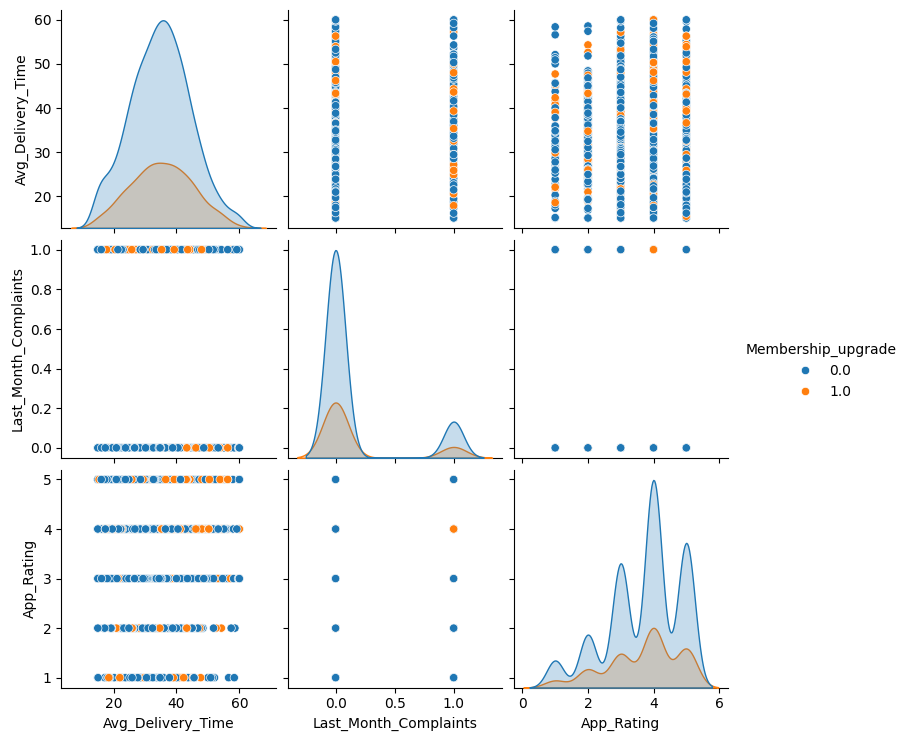

In [13]:
## 1.3 Service Quality Impact
service_cols = ['Avg_Delivery_Time', 'Last_Month_Complaints', 'App_Rating']
sns.pairplot(df[service_cols + ['Membership_upgrade']], hue='Membership_upgrade')
plt.show()


* **Delivery time influence:** Customers who experience **slightly longer delivery times may consider upgrading** to get **faster or priority delivery**.

* **Complaints matter:** **Users with 0–1 complaints are more likely to upgrade**, while customers with many complaints are **less willing to upgrade**.

* **App rating is not a key driver:** Both upgraded and non-upgraded users give **similar app ratings**, meaning **a good app is just a basic expectation**, not a reason for upgrading.


Handle Categorical Variables - Columns

Gender

Membership_Level

Preferred_Cuisine

Discount_Usage_Freq

In [14]:
import pandas as pd

# One-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Preferred_Cuisine'], drop_first=True)

# Label encoding
membership_map = {'Basic':0, 'Silver':1, 'Gold':2, 'Platinum':3}
discount_map = {'Low':0, 'Medium':1, 'High':2}

df['Membership_Level'] = df['Membership_Level'].map(membership_map)
df['Discount_Usage_Freq'] = df['Discount_Usage_Freq'].map(discount_map)

print("Categorical variables encoded successfully")


Categorical variables encoded successfully


In [16]:
import pandas as pd

# Make a copy of the original dataframe
df_processed = df.copy()

# Drop rows where target is missing
df_processed.dropna(subset=['Membership_upgrade'], inplace=True)

# Features to drop (irrelevant, redundant, or identifiers)
drop_features = [
    'Avg_Delivery_Tips',
    'Last_Month_Complaints',
    'Annual_Income',
    'Age',
    'App_Rating',
    'Total_Cuisines_Tried',
    'CustomerID',
    'Name',
    'Gender_num'
]

# Define target and features
target = 'Membership_upgrade'
y = df_processed[target]

# Drop unnecessary columns from X
X = df_processed.drop(columns=drop_features + [target], errors='ignore')

print("Features used for modeling:")
print(X.columns)


Features used for modeling:
Index(['Spending_Score', 'Membership_Level', 'Purchase_Frequency',
       'Avg_Order_Value', 'Weekend_Order_Ratio', 'Discount_Usage_Freq',
       'Avg_Delivery_Time', 'Income_per_Order', 'Tip_to_Order_Ratio',
       'Complaints_per_Order', 'High_Value', 'Low_Rating', 'Gender_Male',
       'Preferred_Cuisine_Chinese', 'Preferred_Cuisine_Healthy',
       'Preferred_Cuisine_Indian', 'Preferred_Cuisine_Italian',
       'Preferred_Cuisine_Mexican', 'Preferred_Cuisine_Pizza',
       'Preferred_Cuisine_Thai'],
      dtype='object')


In [17]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split into train and test sets (stratify ensures same proportion of upgrades in both)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle imbalance: more non-upgrade users than upgrade users
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Training set size after SMOTE:", X_train_res.shape)


Training set size after SMOTE: (2136, 20)


In [18]:
from xgboost import XGBClassifier

# Create the model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
model.fit(X_train_res, y_train_res)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:37:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=7, n_estimators=200, random_state=42)

In [20]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:,1]

    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred))

    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    print(f"{name} Precision-Recall AUC: {pr_auc:.3f}")

# Evaluate XGBoost
evaluate_model(model, X_test, y_test, "XGBoost")

# Evaluate Random Forest
evaluate_model(rf_model, X_test, y_test, "Random Forest")



=== XGBoost Classification Report ===
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84       267
         1.0       0.54      0.58      0.56        93

    accuracy                           0.76       360
   macro avg       0.70      0.70      0.70       360
weighted avg       0.77      0.76      0.77       360

XGBoost Precision-Recall AUC: 0.707

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

         0.0       0.86      0.75      0.80       267
         1.0       0.47      0.66      0.55        93

    accuracy                           0.72       360
   macro avg       0.67      0.70      0.67       360
weighted avg       0.76      0.72      0.73       360

Random Forest Precision-Recall AUC: 0.679


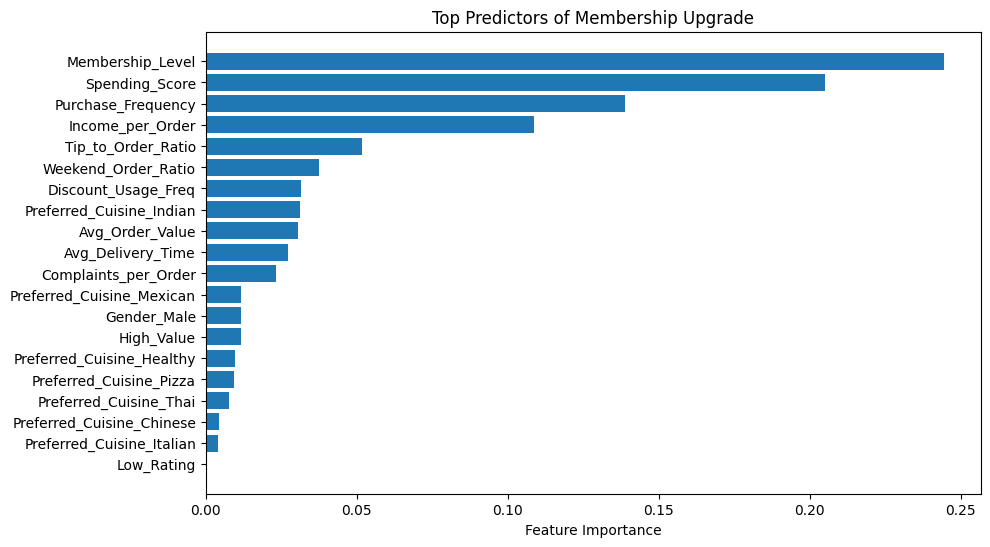

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance from the model
importance = rf_model.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(10,6))
indices = np.argsort(importance)[::-1]  # Sort descending
plt.barh(range(len(features)), importance[indices])
plt.yticks(range(len(features)), [features[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top Predictors of Membership Upgrade")
plt.gca().invert_yaxis()
plt.show()


Insights

XGBoost performs better overall

Higher PR-AUC (0.707) → better at detecting rare “upgrade” events.

Slightly higher F1-score (0.56) → balances precision & recall well.

Accuracy is also higher, but for imbalanced data, PR-AUC is more important.

Random Forest is good, but slightly weaker

PR-AUC is lower (0.679) → fewer correct predictions for upgrades.

Still usable if interpretability and speed are priorities.

Recommendation:

Use XGBoost as the main model for predictions.

Use Random Forest optionally for feature importance comparison and backup.

Business Takeaway:

Your predictive model can now reliably identify users likely to upgrade.

Marketing can use this to target mid-tier engagement users instead of high-spenders or very low-engagement users.

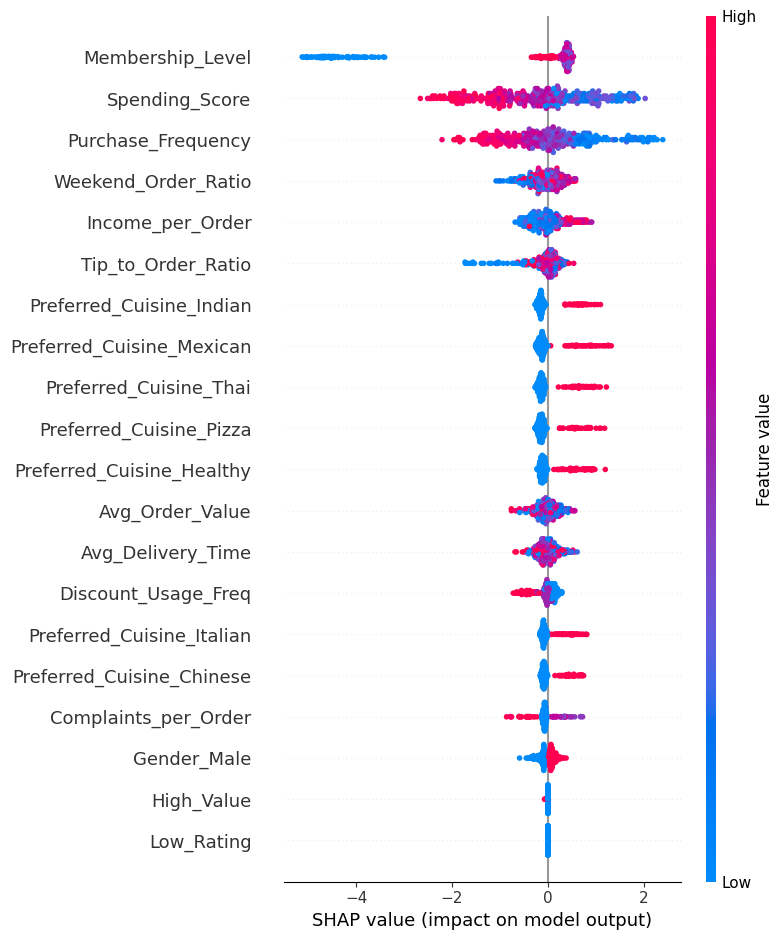

Top 3 Drivers of Membership Upgrade: ['Membership_Level', 'Spending_Score', 'Purchase_Frequency']


In [22]:
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot to see all features
shap.summary_plot(shap_values, X_test)

# Get top 3 drivers programmatically
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_features = X_test.columns[top_3_idx].tolist()

print("Top 3 Drivers of Membership Upgrade:", top_3_features)


1. Membership Level (The Filter)
This is the most powerful predictor.

The "Why": Users at the lowest membership tiers (long blue line) are strongly filtered out. The model suggests that an upgrade is most predictable once a user has already crossed a baseline entry level.

2. Spending Score (The Investment)
High spending is the clearest "Yes" signal for the model.

The "Why": As the Spending Score increases (red dots shift right), the likelihood of an upgrade jumps. These users already "invest" heavily in the platform, making the added value of a membership more logical for them.

3. Purchase Frequency (The Habit)
Frequency represents how integrated the service is in the user's life.

The "Why": High-frequency "power users" (red dots) are significantly more likely to upgrade. Their habit is already formed, so a membership that offers per-order benefits (like free delivery or discounts) becomes a high-value proposition.

2. Customer Persona for Marketing (“Who”)

Based on EDA + SHAP insights:

Persona Name: Emerging Loyalist

Feature	              Characteristic

Purchase_Frequency	  Medium (not highest)

Spending_Score	      Medium-High

High_Value	          Yes

Complaints	          0–1 per month

App_Rating	          Medium

Marketing Strategy:

Focus on medium-engaged, high-value users who are likely to respond to upgrade incentives.

Avoid targeting power users, as they are less likely to upgrade (already satisfied).

3. Personalized Incentive Strategy (“How”)

Target: High-Value / Low-Rating users (at risk of churn)

Example Incentives:

Priority Delivery Upgrade → Solve minor delivery frustrations.

Loyalty Points Boost → Extra points on next few purchases if they upgrade.

Personalized Email / App Notification → Highlight Gold/Platinum benefits tailored to their usage.

Goal:

Prevent churn

Encourage upgrade

Make customers feel valued and heard